# LightGBM Recursive Forecasting Pipeline

This notebook implements a recursive multi-step forecasting pipeline for hourly bike rental demand prediction using LightGBM.

The forecasting features were previously engineered during the preprocessing and exploratory data analysis stage and include:
- autoregressive lag variables,
- rolling-window statistics,
- calendar variables,
- and weather-related explanatory variables.

The objective of this notebook is to:
- train a LightGBM forecasting model,
- generate recursive multi-step forecasts,
- evaluate forecasting performance,
- and analyze feature importance.

In [61]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [62]:
FORECAST_DIR = "../outputs/forecasts"
METRICS_DIR = "../outputs/metrics"
FIGURES_DIR = "../outputs/figures"

os.makedirs(FORECAST_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load Chronological Data Splits

The chronological train-validation-test splits were created previously during the preprocessing and exploratory data analysis stage.

Using pre-generated splits ensures:
- methodological consistency,
- reproducibility,
- and fair comparison across forecasting models.

In [63]:
train = pd.read_csv(
    "../data/processed/train.csv",
    index_col=0,
    parse_dates=True
)

val = pd.read_csv(
    "../data/processed/val.csv",
    index_col=0,
    parse_dates=True
)

test = pd.read_csv(
    "../data/processed/test.csv",
    index_col=0,
    parse_dates=True
)

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (12047, 22)
Validation shape: (3442, 22)
Test shape: (1722, 22)


In [64]:
train.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,cnt,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-08 07:00:00,2011-01-08,1,0,1,7,0,6,0,2,0.16,...,9,2.0,5.0,1.0,84.0,36.0,16.0,63.208333,55.844488,56.458333
2011-01-08 08:00:00,2011-01-08,1,0,1,8,0,6,0,3,0.16,...,15,9.0,2.0,5.0,210.0,95.0,40.0,60.083333,56.721989,56.416667
2011-01-08 09:00:00,2011-01-08,1,0,1,9,0,6,0,3,0.16,...,20,15.0,9.0,2.0,134.0,219.0,32.0,51.958333,47.536237,56.267857
2011-01-08 10:00:00,2011-01-08,1,0,1,10,0,6,0,2,0.18,...,61,20.0,15.0,9.0,63.0,122.0,13.0,47.208333,44.585998,56.196429
2011-01-08 11:00:00,2011-01-08,1,0,1,11,0,6,0,2,0.20,...,62,61.0,20.0,15.0,67.0,45.0,1.0,47.125000,44.557059,56.482143


# Forecasting Feature Space

The processed dataset already contains engineered forecasting variables created during the preprocessing and exploratory analysis stage.

The final feature space combines:
- lag-based autoregressive information,
- rolling-window statistics,
- calendar variables,
- and weather-related explanatory variables.

In [65]:
FEATURES = [

    # lag features
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",

    # rolling features
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",

    # calendar features
    "hr",
    "weekday",
    "mnth",
    "season",
    "workingday",

    # weather features
    "temp",
    "hum",
    "windspeed",
    "weathersit"
]

TARGET = "cnt"

# Create Training, Validation and Test Matrices

In [66]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_val = val[FEATURES]
y_val = val[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12047, 18)
(3442, 18)
(1722, 18)


# LightGBM Training

A gradient boosting forecasting model is trained using the engineered forecasting features.

LightGBM was selected due to:
- strong performance on tabular data,
- ability to model nonlinear relationships,
- robustness to correlated variables,
- and computational efficiency.

In [67]:
model = LGBMRegressor(

    objective="regression",

    num_leaves=31,
    max_depth=8,
    learning_rate=0.05,
    n_estimators=300,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2510
[LightGBM] [Info] Number of data points in the train set: 12047, number of used features: 18
[LightGBM] [Info] Start training from score 161.749564
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# One-Step Validation Forecasts

In [68]:
val_preds = model.predict(X_val)

val_preds[:10]

array([  5.58271757,  26.8112497 , 117.80085568, 395.06892688,
       571.41170752, 297.23394514, 227.83904633, 222.82305414,
       265.5668031 , 288.50339548])

In [69]:
def evaluate_forecasts(
    y_true,
    y_pred,
    y_train
):

    # -----------------------------------
    # MAE
    # -----------------------------------

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    # -----------------------------------
    # RMSE
    # -----------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    # -----------------------------------
    # MASE
    # -----------------------------------

    naive_forecast_error = np.mean(
        np.abs(
            np.diff(y_train)
        )
    )

    mase = mae / naive_forecast_error

    return mae, rmse, mase

# Validation Performance

In [70]:
val_mae, val_rmse, val_mase = evaluate_forecasts(

    y_val,

    val_preds,

    y_train
)

print(f"Validation MAE:   {val_mae:.2f}")
print(f"Validation RMSE:  {val_rmse:.2f}")
print(f"Validation MASE:  {val_mase:.2f}")

Validation MAE:   37.05
Validation RMSE:  57.38
Validation MASE:  0.66


# Recursive Multi-Step Forecasting

The recursive forecasting function iteratively predicts future observations while dynamically updating:
- lag variables,
- rolling statistics,
- and calendar-based time features.

This allows the forecasting pipeline to realistically simulate future temporal progression during multi-step prediction.

In [71]:
def recursive_forecast(
    model,
    history_df,
    forecast_horizon=24
):

    history = history_df.copy()

    predictions = []

    for step in range(forecast_horizon):

        # -----------------------------------
        # LAST AVAILABLE ROW
        # -----------------------------------

        row = history.iloc[-1:].copy()

        # -----------------------------------
        # ADVANCE TIME
        # -----------------------------------

        next_timestamp = (
            row.index[0]
            + pd.Timedelta(hours=1)
        )

        # -----------------------------------
        # UPDATE CALENDAR FEATURES
        # -----------------------------------

        row.index = [next_timestamp]

        row["hr"] = next_timestamp.hour

        row["weekday"] = next_timestamp.weekday()

        row["mnth"] = next_timestamp.month

        row["workingday"] = int(
            next_timestamp.weekday() < 5
        )

        # -----------------------------------
        # UPDATE LAG FEATURES
        # -----------------------------------

        row["lag_1"] = history["cnt"].iloc[-1]

        row["lag_2"] = history["cnt"].iloc[-2]

        row["lag_3"] = history["cnt"].iloc[-3]

        row["lag_24"] = history["cnt"].iloc[-24]

        row["lag_48"] = history["cnt"].iloc[-48]

        row["lag_168"] = history["cnt"].iloc[-168]

        # -----------------------------------
        # UPDATE ROLLING FEATURES
        # -----------------------------------

        row["rolling_mean_24"] = (
            history["cnt"]
            .iloc[-24:]
            .mean()
        )

        row["rolling_std_24"] = (
            history["cnt"]
            .iloc[-24:]
            .std()
        )

        row["rolling_mean_168"] = (
            history["cnt"]
            .iloc[-168:]
            .mean()
        )

        # -----------------------------------
        # MODEL PREDICTION
        # -----------------------------------

        X_row = row[FEATURES]

        pred = model.predict(X_row)[0]

        predictions.append(pred)

        # -----------------------------------
        # FEED PREDICTION BACK
        # -----------------------------------

        new_row = row.copy()

        new_row["cnt"] = pred

        history = pd.concat([
            history,
            new_row
        ])

    return predictions

# Rolling Recursive Validation

A rolling recursive evaluation strategy is used to simulate realistic forecasting conditions.

The model:
- recursively predicts the next 24 hours,
- compares predictions with the true validation observations,
- then moves the forecasting window forward.

This setup provides a more robust evaluation of multi-step forecasting performance.

In [72]:
forecast_horizon = 24

all_recursive_preds = []

all_recursive_actuals = []

forecast_starts = range(
    0,
    len(val) - forecast_horizon,
    forecast_horizon
)

for start in forecast_starts:

    # -----------------------------------
    # HISTORY AVAILABLE TO THE MODEL
    # -----------------------------------

    history = pd.concat([

        train,

        val.iloc[:start]

    ])

    # -----------------------------------
    # TRUE FUTURE VALUES
    # -----------------------------------

    actual_future = val.iloc[
        start:start + forecast_horizon
    ]["cnt"].values

    # -----------------------------------
    # RECURSIVE FORECAST
    # -----------------------------------

    recursive_preds = recursive_forecast(
        model,
        history,
        forecast_horizon=forecast_horizon
    )

    # -----------------------------------
    # STORE RESULTS
    # -----------------------------------

    all_recursive_preds.extend(
        recursive_preds
    )

    all_recursive_actuals.extend(
        actual_future
    )

# Recursive Forecasting Performance

In [73]:
recursive_mae, recursive_rmse, recursive_mase = evaluate_forecasts(

    all_recursive_actuals,

    all_recursive_preds,

    y_train
)

print(f"Recursive MAE:   {recursive_mae:.2f}")
print(f"Recursive RMSE:  {recursive_rmse:.2f}")
print(f"Recursive MASE:  {recursive_mase:.2f}")

Recursive MAE:   66.40
Recursive RMSE:  99.89
Recursive MASE:  1.19


# Recursive Forecast Visualization

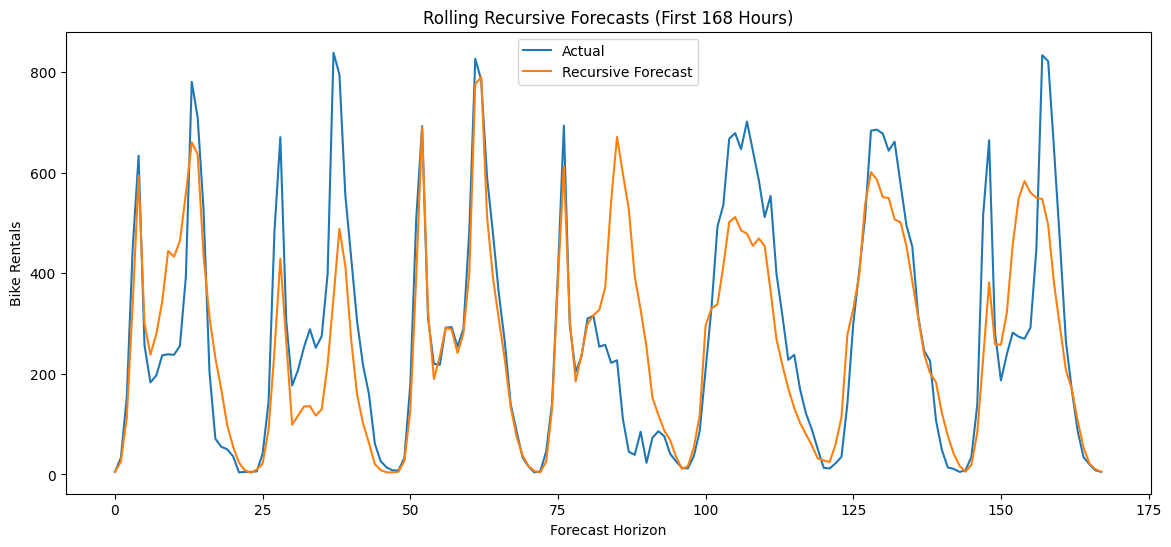

In [74]:
plt.figure(figsize=(14,6))

plt.plot(
    all_recursive_actuals[:168],
    label="Actual"
)

plt.plot(
    all_recursive_preds[:168],
    label="Recursive Forecast"
)

plt.title(
    "Rolling Recursive Forecasts (First 168 Hours)"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

# Hyperparameter Tuning

Several LightGBM hyperparameter configurations are evaluated on the validation set.

The tuning process focuses on:
- tree complexity,
- learning rate,
- and ensemble size.

The best-performing configuration is selected based on validation forecasting performance.

In [75]:
configs = [

    {
        "num_leaves": 31,
        "max_depth": 8,
        "learning_rate": 0.05,
        "n_estimators": 300
    },

    {
        "num_leaves": 64,
        "max_depth": 10,
        "learning_rate": 0.03,
        "n_estimators": 500
    },

    {
        "num_leaves": 128,
        "max_depth": 12,
        "learning_rate": 0.01,
        "n_estimators": 700
    }
]

In [76]:
tuning_results = []

for config in configs:

    print("Testing configuration:")
    print(config)

    # -----------------------------------
    # TRAIN MODEL
    # -----------------------------------

    tuned_model = LGBMRegressor(

        objective="regression",

        random_state=42,

        importance_type="gain",

        **config
    )

    tuned_model.fit(
        X_train,
        y_train
    )

    # -----------------------------------
    # VALIDATION PREDICTIONS
    # -----------------------------------

    val_preds = tuned_model.predict(
        X_val
    )

    # -----------------------------------
    # METRICS
    # -----------------------------------

    val_mae, val_rmse, val_mase = evaluate_forecasts(

        y_val,

        val_preds,

        y_train
    )

    tuning_results.append({

        **config,

        "MAE": val_mae,
        "RMSE": val_rmse,
        "MASE": val_mase
    })

    print(f"MAE:   {val_mae:.2f}")
    print(f"RMSE:  {val_rmse:.2f}")
    print(f"MASE:  {val_mase:.2f}")

    print("-" * 50)

Testing configuration:
{'num_leaves': 31, 'max_depth': 8, 'learning_rate': 0.05, 'n_estimators': 300}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2510
[LightGBM] [Info] Number of data points in the train set: 12047, number of used features: 18
[LightGBM] [Info] Start training from score 161.749564
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [77]:
tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = tuning_results_df.sort_values(
    "MASE"
)

tuning_results_df

,num_leaves,max_depth,learning_rate,n_estimators,MAE,RMSE,MASE
1,64,10,0.03,500,36.342217,56.855147,0.648630
0,31,8,0.05,300,37.045922,57.382221,0.661189
2,128,12,0.01,700,37.453149,58.867969,0.668457


# Best Model Selection

The best-performing configuration is selected based on the lowest validation MASE score.

In [78]:
best_config = tuning_results_df.iloc[0]

best_config

num_leaves        64.000000
max_depth         10.000000
learning_rate      0.030000
n_estimators     500.000000
MAE               36.342217
RMSE              56.855147
MASE               0.648630
Name: 1, dtype: float64

In [79]:
final_model = LGBMRegressor(

    objective="regression",

    random_state=42,

    importance_type="gain",

    num_leaves=int(best_config["num_leaves"]),
    max_depth=int(best_config["max_depth"]),
    learning_rate=best_config["learning_rate"],
    n_estimators=int(best_config["n_estimators"])
)

final_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000326 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2510
[LightGBM] [Info] Number of data points in the train set: 12047, number of used features: 18
[LightGBM] [Info] Start training from score 161.749564
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,10
,learning_rate,np.float64(0.03)
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Final Validation Forecasts

Validation forecasts are generated using the best-performing LightGBM configuration selected during hyperparameter tuning.

In [80]:
final_val_preds = final_model.predict(
    X_val
)

# Final Validation Performance

In [81]:
final_val_mae, final_val_rmse, final_val_mase = evaluate_forecasts(

    y_val,

    final_val_preds,

    y_train
)

print(f"Final Validation MAE:   {final_val_mae:.2f}")
print(f"Final Validation RMSE:  {final_val_rmse:.2f}")
print(f"Final Validation MASE:  {final_val_mase:.2f}")

Final Validation MAE:   36.34
Final Validation RMSE:  56.86
Final Validation MASE:  0.65


# Rolling Recursive Validation

A rolling recursive forecasting strategy is used to simulate realistic multi-step forecasting conditions.

The model recursively predicts the next 24 hours while feeding previous predictions back into the forecasting feature space.

In [82]:
forecast_horizon = 24

all_recursive_preds = []

all_recursive_actuals = []

forecast_starts = range(

    0,

    len(val) - forecast_horizon,

    forecast_horizon
)

for start in forecast_starts:

    # -----------------------------------
    # AVAILABLE HISTORY
    # -----------------------------------

    history = pd.concat([

        train,

        val.iloc[:start]

    ])

    # -----------------------------------
    # TRUE FUTURE VALUES
    # -----------------------------------

    actual_future = val.iloc[
        start:start + forecast_horizon
    ]["cnt"].values

    # -----------------------------------
    # RECURSIVE FORECAST
    # -----------------------------------

    recursive_preds = recursive_forecast(

        final_model,

        history,

        forecast_horizon=forecast_horizon
    )

    # -----------------------------------
    # STORE RESULTS
    # -----------------------------------

    all_recursive_preds.extend(
        recursive_preds
    )

    all_recursive_actuals.extend(
        actual_future
    )

# Recursive Forecasting Performance

In [83]:
recursive_mae, recursive_rmse, recursive_mase = evaluate_forecasts(

    all_recursive_actuals,

    all_recursive_preds,

    y_train
)

print(f"Recursive MAE:   {recursive_mae:.2f}")
print(f"Recursive RMSE:  {recursive_rmse:.2f}")
print(f"Recursive MASE:  {recursive_mase:.2f}")

Recursive MAE:   63.37
Recursive RMSE:  98.63
Recursive MASE:  1.13


# Recursive Forecast Visualization

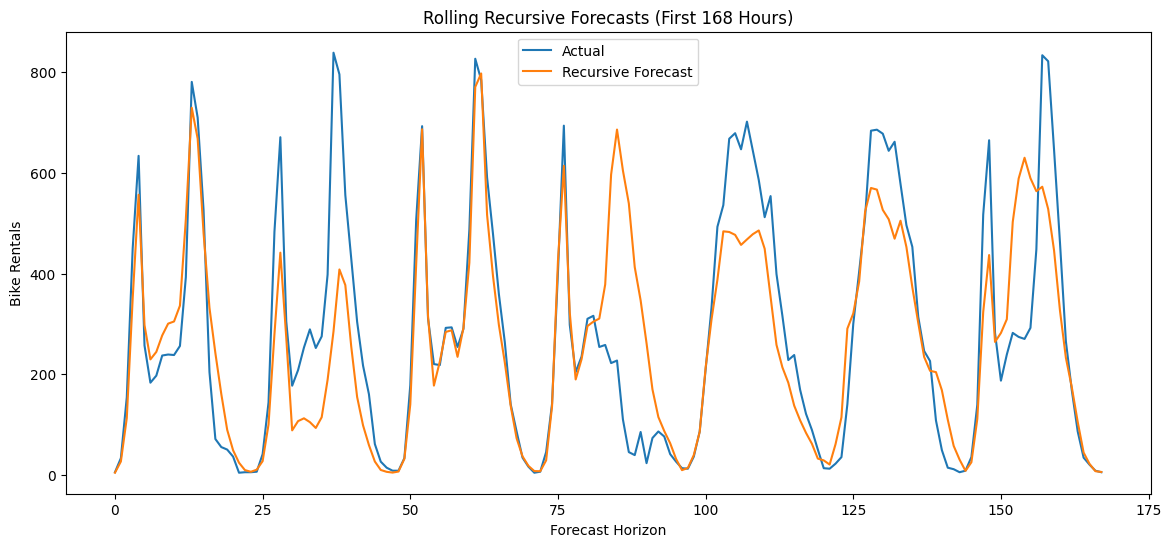

In [84]:
plt.figure(figsize=(14,6))

plt.plot(

    all_recursive_actuals[:168],

    label="Actual"
)

plt.plot(

    all_recursive_preds[:168],

    label="Recursive Forecast"
)

plt.title(
    "Rolling Recursive Forecasts (First 168 Hours)"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

# Feature Importance Analysis

Feature importance analysis is used to identify the most influential forecasting variables used by the LightGBM model.

Gain-based importance is utilized because it better reflects the predictive contribution of individual variables during tree construction.

In [85]:
importance_df = pd.DataFrame({

    "feature": FEATURES,

    "importance": final_model.feature_importances_

})

importance_df = importance_df.sort_values(

    "importance",

    ascending=False
)

importance_df

,feature,importance
0,lag_1,3.284059e+09
3,lag_24,5.806103e+08
9,hr,2.981625e+08
5,lag_168,2.168033e+08
2,lag_3,1.063745e+08
1,lag_2,5.064042e+07
13,workingday,3.946867e+07
14,temp,2.877390e+07
17,weathersit,2.841663e+07
8,rolling_mean_168,2.493040e+07


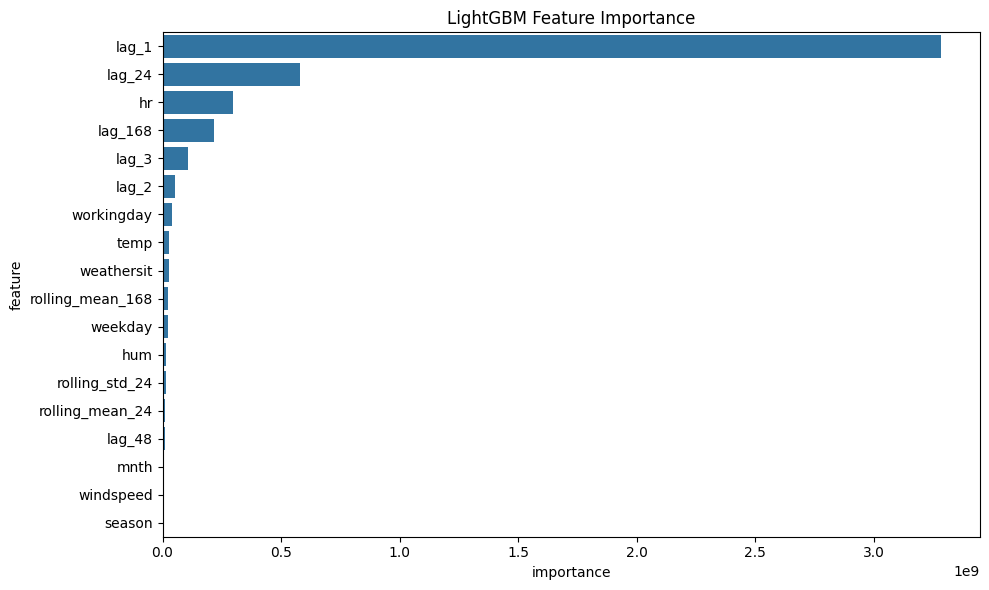

In [86]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df,

    x="importance",

    y="feature"
)

plt.title(
    "LightGBM Feature Importance"
)

plt.tight_layout()

plt.savefig(

    f"{FIGURES_DIR}/lightgbm_feature_importance.png"
)

plt.show()

# Save Forecast Outputs

In [87]:
forecast_df = pd.DataFrame({

    "actual": all_recursive_actuals,

    "prediction": all_recursive_preds
})

forecast_df.to_csv(

    f"{FORECAST_DIR}/recursive_forecasts.csv",

    index=False
)

forecast_df.head()

,actual,prediction
0,5,4.035176
1,33,26.344286
2,154,112.604764
3,450,350.745745
4,634,556.659710


In [88]:
tuning_results_df.to_csv(

    f"{METRICS_DIR}/lightgbm_tuning_results.csv",

    index=False
)

tuning_results_df

,num_leaves,max_depth,learning_rate,n_estimators,MAE,RMSE,MASE
1,64,10,0.03,500,36.342217,56.855147,0.648630
0,31,8,0.05,300,37.045922,57.382221,0.661189
2,128,12,0.01,700,37.453149,58.867969,0.668457


# Final Test Set Evaluation

The final forecasting model is evaluated on the unseen test set using the same rolling recursive forecasting strategy.

This provides an unbiased estimate of real-world forecasting performance.

In [89]:
forecast_horizon = 24

test_recursive_preds = []

test_recursive_actuals = []

forecast_starts = range(

    0,

    len(test) - forecast_horizon,

    forecast_horizon
)

for start in forecast_starts:

    # -----------------------------------
    # AVAILABLE HISTORY
    # -----------------------------------

    history = pd.concat([

        train,

        val,

        test.iloc[:start]

    ])

    # -----------------------------------
    # TRUE FUTURE VALUES
    # -----------------------------------

    actual_future = test.iloc[
        start:start + forecast_horizon
    ]["cnt"].values

    # -----------------------------------
    # RECURSIVE FORECAST
    # -----------------------------------

    recursive_preds = recursive_forecast(

        final_model,

        history,

        forecast_horizon=forecast_horizon
    )

    # -----------------------------------
    # STORE RESULTS
    # -----------------------------------

    test_recursive_preds.extend(
        recursive_preds
    )

    test_recursive_actuals.extend(
        actual_future
    )

# Final Test Performance

In [90]:
test_mae, test_rmse, test_mase = evaluate_forecasts(

    test_recursive_actuals,

    test_recursive_preds,

    y_train
)

print(f"Test MAE:   {test_mae:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")
print(f"Test MASE:  {test_mase:.2f}")

Test MAE:   68.59
Test RMSE:  105.13
Test MASE:  1.22


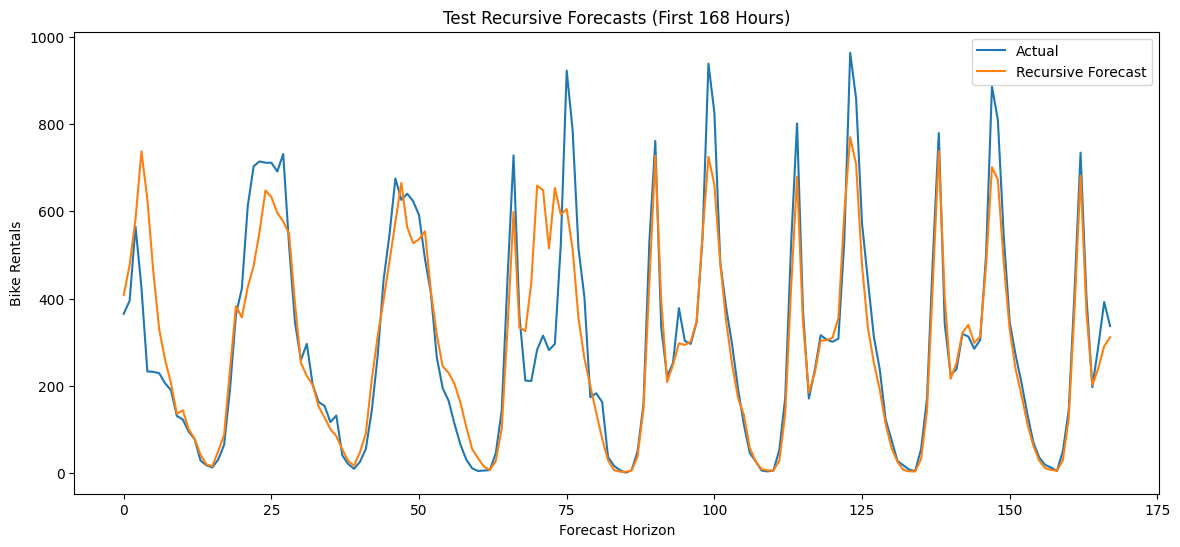

In [91]:
plt.figure(figsize=(14,6))

plt.plot(

    test_recursive_actuals[:168],

    label="Actual"
)

plt.plot(

    test_recursive_preds[:168],

    label="Recursive Forecast"
)

plt.title(
    "Test Recursive Forecasts (First 168 Hours)"
)

plt.xlabel("Forecast Horizon")

plt.ylabel("Bike Rentals")

plt.legend()

plt.show()

# Save Forecast Outputs

In [92]:
forecast_df = pd.DataFrame({

    "actual": test_recursive_actuals,

    "prediction": test_recursive_preds
})

forecast_df.to_csv(

    f"{FORECAST_DIR}/lightgbm_test_recursive_forecasts.csv",

    index=False
)

forecast_df.head()

,actual,prediction
0,365,408.449146
1,395,476.440640
2,565,582.016487
3,425,737.213957
4,233,628.078624


In [93]:
metrics_df = pd.DataFrame({

    "metric": ["MAE", "RMSE", "MASE"],

    "value": [

        test_mae,

        test_rmse,

        test_mase
    ]
})

metrics_df.to_csv(

    f"{METRICS_DIR}/lightgbm_test_metrics.csv",

    index=False
)

metrics_df

,metric,value
0,MAE,68.586502
1,RMSE,105.132059
2,MASE,1.224120


In [94]:
tuning_results_df.to_csv(

    f"{METRICS_DIR}/lightgbm_tuning_results.csv",

    index=False
)

tuning_results_df

,num_leaves,max_depth,learning_rate,n_estimators,MAE,RMSE,MASE
1,64,10,0.03,500,36.342217,56.855147,0.648630
0,31,8,0.05,300,37.045922,57.382221,0.661189
2,128,12,0.01,700,37.453149,58.867969,0.668457


# Summary

A recursive multi-step LightGBM forecasting pipeline was successfully implemented for hourly bike rental demand prediction.

The forecasting framework combines:
- autoregressive lag features,
- rolling-window statistics,
- calendar variables,
- and weather-related explanatory information.

The final model was selected through validation-based hyperparameter tuning and evaluated on an unseen test set using a rolling recursive forecasting strategy. The recursive forecasting setup realistically simulated real-world deployment conditions by iteratively feeding model predictions back into the forecasting feature space.

The results demonstrated that:
- LightGBM effectively captured the strong temporal structure of the series,
- lag-based variables were highly informative forecasting predictors,
- and the model successfully reproduced recurring daily demand cycles.

Feature importance analysis additionally confirmed the dominant role of autoregressive and seasonal forecasting features.

The resulting pipeline provides:
- a scalable machine learning forecasting framework,
- interpretable forecasting behavior